In [17]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import os

import functions.data_wrangling as dw

In [14]:
path = '/home/links/ct715/data_storage/reanalysis/jra55_daily/processed_efp'

path_6h = os.path.join(path, 'k123_6h_ubar_epf-pr-QG_1MS_1958-2016.nc')
ds_6h = xr.open_dataset(path_6h)
ds_6h

<xarray.Dataset> Size: 5GB
Dimensions:      (time: 708, level: 37, lat: 73, lon: 144)
Coordinates:
  * lon          (lon) float64 1kB 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
  * lat          (lat) float64 584B -90.0 -87.5 -85.0 -82.5 ... 85.0 87.5 90.0
  * level        (level) float64 296B 1e+03 975.0 950.0 925.0 ... 3.0 2.0 1.0
    year         (time) int64 6kB ...
  * time         (time) datetime64[ns] 6kB 1958-01-31 1958-02-28 ... 2016-12-31
Data variables: (12/17)
    u            (time, level, lat, lon) float32 1GB ...
    v            (time, level, lat, lon) float32 1GB ...
    t            (time, level, lat, lon) float32 1GB ...
    omega        (time, level, lat, lon) float32 1GB ...
    ubar         (time, level, lat) float32 8MB ...
    ep1_QG       (time, level, lat) float64 15MB ...
    ...           ...
    div1_QG_123  (time, level, lat) float64 15MB ...
    div2_QG_123  (time, level, lat) float64 15MB ...
    ep1_QG_gt3   (time, level, lat) float64 15MB ...
    ep2_QG_gt3   (time, level, lat) float64 15MB ...
    div1_QG_gt3  (time, level, lat) float64 15MB ...
    div2_QG_gt3  (time, level, lat) float64 15MB ...

In [15]:
djf = ds_6h.sel(lat=slice(0,90))
djf = dw.seasonal_mean(djf, season='djf')
djf

<xarray.Dataset> Size: 197MB
Dimensions:      (time: 60, level: 37, lat: 37, lon: 144)
Coordinates:
  * lon          (lon) float64 1kB 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
  * lat          (lat) float64 296B 0.0 2.5 5.0 7.5 10.0 ... 82.5 85.0 87.5 90.0
  * level        (level) float64 296B 1e+03 975.0 950.0 925.0 ... 3.0 2.0 1.0
  * time         (time) datetime64[ns] 480B 1957-12-01 1958-12-01 ... 2016-12-01
Data variables: (12/17)
    u            (time, level, lat, lon) float32 47MB -1.824 -1.511 ... -19.83
    v            (time, level, lat, lon) float32 47MB 2.331 2.197 ... -10.78
    t            (time, level, lat, lon) float32 47MB 298.2 298.4 ... 226.9
    omega        (time, level, lat, lon) float32 47MB -0.001179 ... -0.0001017
    ubar         (time, level, lat) float32 329kB -2.479 -3.01 ... 9.492e-05
    ep1_QG       (time, level, lat) float64 657kB 0.575 -2.444 ... 0.005138
    ...           ...
    div1_QG_123  (time, level, lat) float64 657kB -0.8281 -0.5857 ... -2.274e+12
    div2_QG_123  (time, level, lat) float64 657kB 0.0 0.5696 ... -1.38 0.0
    ep1_QG_gt3   (time, level, lat) float64 657kB -0.5695 -1.168 ... 1.703e-06
    ep2_QG_gt3   (time, level, lat) float64 657kB 0.0 -6.323e-05 ... 1.776e-26
    div1_QG_gt3  (time, level, lat) float64 657kB -0.1566 -0.1418 ... -7.538e+08
    div2_QG_gt3  (time, level, lat) float64 657kB 0.0 0.03982 ... -3.185e-22

Calculating correlation for div1_QG...
Calculating correlation for div1_QG_123...
Calculating correlation for div1_QG_gt3...


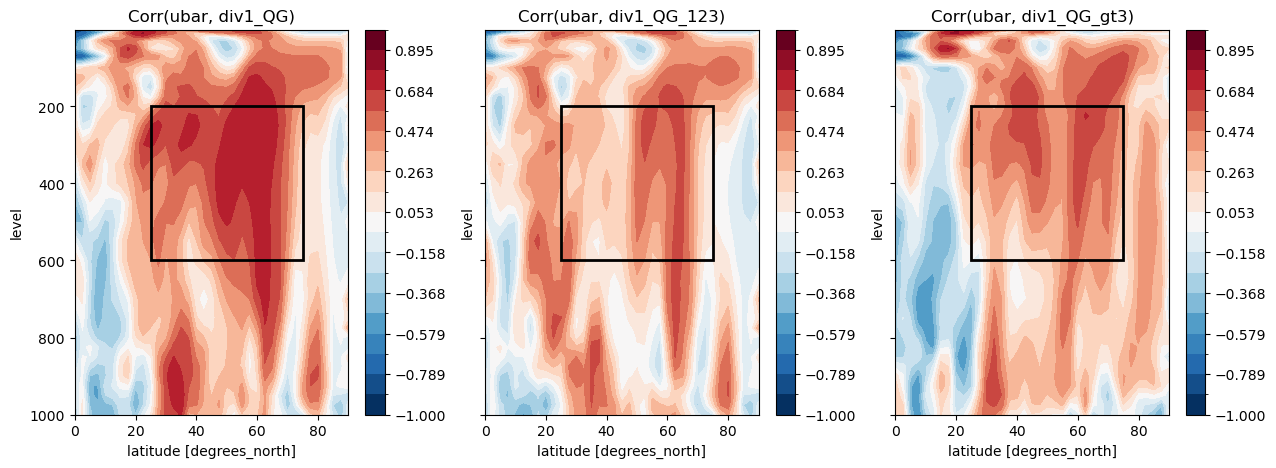

In [18]:


corr_vars = ['div1_QG', 'div1_QG_123', 'div1_QG_gt3']
fig, axes = plt.subplots(ncols=3, figsize=(15, 5), sharey=True)

for i, vars in enumerate(corr_vars):
    print(f'Calculating correlation for {vars}...')
    corr = xr.corr(djf['ubar'], djf[vars], dim='time')
    corr.plot.contourf(ax=axes[i], vmin=-1, vmax=1, cmap='RdBu_r', 
                       yincrease=False, levels=20)
    axes[i].set_title(f'Corr(ubar, {vars})')
    
    # Add box for 200-600 hPa, 25-75°N
    box = Rectangle((25, 200), width=50, height=400, 
                    fill=False, edgecolor='black', linewidth=2)
    axes[i].add_patch(box)

plt.show()